Reading up on building a basic RAG system, using different embedding strategies. This helps us to know which embedding strategy will work best for the document types that we have

https://pub.towardsai.net/mastering-rag-choosing-the-right-vector-embedding-model-for-your-rag-application-bbb57517890e

Testing out pdf parsing using PyMuPDF

In [3]:
!pip install pymupdf.layout
!pip install PyMuPDF
!pip install pdfplumber
!pip install pymupdf4llm
!pip install matplotlib
!pip install unstructured
# !pip install langchain-huggingface sentence-transformers
# !pip install --upgrade torch transformers accelerate
!pip install --upgrade torchvision
!pip install langchain_qdrant
!pip install --upgrade qdrant-client langchain-qdrant

  Using cached pdfplumber-0.11.9-py3-none-any.whl.metadata (43 kB)
  Using cached pdfminer_six-20251230-py3-none-any.whl.metadata (4.3 kB)
Using cached pdfplumber-0.11.9-py3-none-any.whl (60 kB)
Using cached pdfminer_six-20251230-py3-none-any.whl (6.6 MB)
  Attempting uninstall: pdfminer.six
    Found existing installation: pdfminer.six 20260107
    Uninstalling pdfminer.six-20260107:
      Successfully uninstalled pdfminer.six-20260107
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [pdfplumber]2 [pdfplumber]


Trying to test pdf parser

In [2]:
import fitz  # PyMuPDF
import pymupdf.layout
import pymupdf4llm
doc = fitz.open("../../info/MyNewdataset.pdf")

json = pymupdf4llm.to_json(doc)
print(json)


{"filename": "../../info/MyNewdataset.pdf", "page_count": 4, "toc": [], "pages": [{"page_number": 1, "width": 841.9199829101562, "height": 1191.1199951171875, "boxes": [{"x0": 25.51171875, "y0": 15.929421424865723, "x1": 85.9620361328125, "y1": 22.882104873657227, "boxclass": "page-header", "image": null, "table": null, "textlines": [{"bbox": [25.51171875, 15.929421424865723, 85.9620361328125, 22.882104873657227], "spans": [{"size": 7.994999885559082, "flags": 0, "bidi": 0, "char_flags": 16, "font": "ArialMT", "color": 0, "alpha": 255, "ascender": 0.800000011920929, "descender": -0.20000000298023224, "text": "3/26/26, 8:52 AM", "origin": [25.51171875, 21.75], "bbox": [25.51171875, 15.929421424865723, 85.9620361328125, 22.882104873657227], "line": 0, "block": 31, "dir": [1.0, 0.0]}]}]}, {"x0": 440.30859375, "y0": 16.027015686035156, "x1": 493.18695068359375, "y1": 23.432540893554688, "boxclass": "page-header", "image": null, "table": null, "textlines": [{"bbox": [440.30859375, 16.027015

Testing out unstructured pdf parser

mac: brew install poppler tesseract

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from unstructured.partition.auto import partition

In [20]:
print(os.getcwd())
path = "../data/train/pdfs_train/0b85477387a9d0cc33fca0f4becaa0e5.pdf"
os.path.exists(path)

/Users/bebs/Documents/School/DAT 560/DAT560project/src/notebooks


True

In [21]:
# !pip install "unstructured[pdf]"
blocks = partition(filename=path)

In [22]:
for block in blocks:
    print(f"{block.category}: {block.text}")


Header: NMR&D News
Title: Volume IV, Issue 12
Title: In this issue…
NarrativeText: 2 CO‟s Messages 3 Building Afghan Medical Capacity 4 USNS Mercy Pacific Partnership 5 DoD Bone Marrow Donor Program 6 ID Joint Planning Group 7 Capacity Building in Liberia 8 Kazakh Scientists Train at NMRC 9 Patient Condition Occurrence Tool 10 Combat Casualty Research Team 11 Accelerating Technology Transfer 12 NMRC Hosts Dining Out 13 Villasante Speaks at Notre Dame 14 Keane-Myers Speaks at Hopkins 14 Cub Scouts Learn Flag Etiquette 15 NMRC High School Outreach NMRC Officers Teach Science 15 2012 Combined Federal Campaign 16 16 Ombudsman‟s Note
NarrativeText: NMR&D News is an authorized publica- tion of the Naval Medical Research Center, 503 Robert Grant Avenue, Silver Spring, MD 20910. NMR&D News is published monthly by the NMRC Public Affairs Office, 301-319-9378 or svc.pao.nmrc@med.navy.mil .
NarrativeText: Commanding Officer Capt. John W. Sanders
Title: Executive Officer Capt. Elizabeth Montcalm-S

Test Embedding using KaLM

In [7]:
from langchain_huggingface import HuggingFaceEmbeddings
import sentence_transformers
from transformers import PreTrainedModel


# Define the KaLM model from Hugging Face
model_name = "KaLM-Embedding/KaLM-embedding-multilingual-mini-instruct-v2.5"
model_kwargs = {'device': 'cpu'} # Change to 'cuda' for GPU
encode_kwargs = {'normalize_embeddings': True}

# Initialize LangChain embedding class
kalm_embeddings = HuggingFaceEmbeddings(
    model_name=model_name,
    model_kwargs=model_kwargs,
    encode_kwargs=encode_kwargs
)

# Use the model to embed text
text = "This is a test document."
embedding = kalm_embeddings.embed_query(text)
print(embedding) # Outputs the embedding vector
print(len(embedding)) # Outputs the dimension of the embedding


/opt/homebrew/Caskroom/miniconda/base/envs/dat540/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 290/290 [00:00<00:00, 5284.24it/s]


[-0.0383729450404644, -0.026311155408620834, 0.01223372109234333, -0.019534660503268242, -0.07257401943206787, 0.02025051787495613, -0.028576504439115524, -0.0037212723400443792, -0.0028800664003938437, 0.03383132442831993, -0.04248383268713951, 0.06163700670003891, 0.0648241937160492, -0.022169407457113266, -0.02616947330534458, -0.012430868111550808, -0.024700095877051353, 0.09194932132959366, -0.023991065099835396, -0.023246068507432938, -0.0024326490238308907, 0.07014287263154984, -0.026182491332292557, 0.09707958996295929, -0.08901002258062363, -0.03617897629737854, 0.07076911628246307, -0.08108171075582504, -0.019471367821097374, 0.03488931059837341, 0.014957066625356674, 0.02167549729347229, -0.06686847656965256, -0.0413714163005352, 0.016199979931116104, 0.07999475300312042, -0.0491577573120594, 0.020232416689395905, 0.022344456985592842, 0.011296095326542854, -0.004685695748776197, -0.047681257128715515, 0.01805032789707184, 0.04005235433578491, -0.026294870302081108, 0.025115

Test storing embedding on vector db

In [12]:

from unstructured.partition.pdf import partition_pdf
from qdrant_client import QdrantClient
from qdrant_client.models import Distance, VectorParams, PointStruct
from sentence_transformers import SentenceTransformer
import uuid

COLLECTION_NAME = "mmdocir_baseline"

# Connect to the local Qdrant database you started with Docker
print("Connecting to Qdrant...")
client = QdrantClient(url="http://localhost:6333")

# Delete the existing incorrect collection if it exists
if client.collection_exists(collection_name=COLLECTION_NAME):
    client.delete_collection(collection_name=COLLECTION_NAME)
    print(f"Deleted old collection: {COLLECTION_NAME}")

# Create a fresh storage collection with the correct size (896)
client.create_collection(
    collection_name=COLLECTION_NAME,
    vectors_config=VectorParams(size=896, distance=Distance.COSINE),
)


print("Translating text to vectors and uploading to Qdrant...")

points_to_upload = []

# Loop through each extracted block of text
for i, block in enumerate(blocks):
    # Skip empty blocks
    if not block.text.strip():
        continue
        
    # Turn the text into a math vector using our LangChain embedding model
    vector = kalm_embeddings.embed_query(block.text) 
    
    # Create a unique ID for this chunk
    point_id = str(uuid.uuid4()) 
    
    # Package it up for Qdrant: ID + Math Vector + Original Text (Payload)
    point = PointStruct(
        id=point_id,
        vector=vector,
        payload={
            "source": path,
            "text": block.text,
            "category": block.category,
            "chunk_index": i
        }
    )
    points_to_upload.append(point)

# Send the massive batch of data to Qdrant all at once
if points_to_upload:
    client.upsert(
        collection_name=COLLECTION_NAME,
        points=points_to_upload
    )

print("✅ Success! PDF text is now indexed and ready for retrieval.")
# ...existing code...

Connecting to Qdrant...
Deleted old collection: mmdocir_baseline
Translating text to vectors and uploading to Qdrant...
✅ Success! PDF text is now indexed and ready for retrieval.


simple test query with vector db

In [16]:
#embed user query
query = "what are the stages in the annotation pipeline?"
query_vector = kalm_embeddings.embed_query(query)

# Perform a similarity search in Qdrant using the query vector
search_results = client.query_points(
    collection_name=COLLECTION_NAME,
    query=query_vector,
    limit=5  # Number of similar items to retrieve
)

# Print the search results
print( search_results)
# for result in search_results:
#     print(f"ID: {result.id}, Score: {result.score}")
#     print(f"Text: {result.payload['text']}\n")

points=[ScoredPoint(id='9fb73b39-0944-45b9-9bd5-9704c47a73aa', version=1, score=0.74691427, payload={'source': '../../info/MyNewdataset.pdf', 'text': 'The annotation pipeline of includes three stages. 1. (1) Data collection: We collect 364 long documents and 2,193 QA pairs from MMLongBench-Doc and DocBench, selecting datasets that include accessible original documents, diverse domains (e.g., academic, legal, \x00nancial), and rich multi-modal content such as text, \x00gures, tables, and layouts. The average document length exceeds 65 pages, ensuring the benchmark re\x00ects real-world document complexity. (2) Question Filtering & Adaptation:', 'category': 'NarrativeText', 'chunk_index': 34}, vector=None, shard_key=None, order_value=None), ScoredPoint(id='6f0d6abb-bc1d-4ff7-986b-2d4a72049eca', version=1, score=0.58377266, payload={'source': '../../info/MyNewdataset.pdf', 'text': 'To ensure alignment with retrieval objectives, we \x00lter out questions that are unsuitable for document-ba

DOCKER COMPOSE FOR QDrant

services:
  qdrant:
    image: qdrant/qdrant:latest
    container_name: qdrant_db
    ports:
      - "6333:6333"
    volumes:
      - ./qdrant_data:/qdrant/storage
    restart: always

Testing out kiran's chunking class, made some update will discuss with him tomorrow

Also added enhanced_hierarchical for cross page

In [1]:
import json
from typing import List, Dict, Any

class Chunking:
    HEADING_CATEGORIES = {"Title", "Header"}

    def __init__(self, blocks: List):
        self.blocks = blocks

    @staticmethod
    def _make_chunk(texts: List[str], extra_meta: Dict[str, Any] = None) -> Dict[str, Any]:
        """Helper function to store char_len which can be useful downstream"""
        chunk_text = " ".join(texts)
        chunk = {"text": chunk_text, "char_len": len(chunk_text)}
        if extra_meta:
            chunk.update(extra_meta)
        return chunk

    def fixed_size(self, max_chars: int = 1000) -> List[Dict[str, Any]]:
        """Concatenate blocks until max_chars is exceeded, then start a new chunk."""

        current_texts, chunks = [], []
        text_len, blocks_count = 0, len(self.blocks)
        for i, block in enumerate(self.blocks):
            text = block.text.strip()
            if not text:
                continue

            text_len += len(text)
            current_texts.append(text)
            if text_len > max_chars or i == blocks_count - 1:
                chunks.append(Chunking._make_chunk(current_texts))
                current_texts = []
                text_len = 0
        return chunks

    def sliding_window(
        self, window_charts: int = 1000, overlap_chars: int = 200
    ) -> List[Dict[str, Any]]:
        """
        Fixed-size windows with overlap so context at chunk boundaries
        is not lost. Good for dense text documents.
        """
        current_texts, chunks = [], []
        text_len, blocks_count = 0, len(self.blocks)
        for i, block in enumerate(self.blocks):
            text = block.text.strip()
            if not text:
                continue

            text_len += len(text)
            current_texts.append(text)
            if text_len > window_charts or i == blocks_count - 1:
                if chunks:
                    prev_text = chunks[-1]["text"][-overlap_chars:]  # use the actual text from the last chunk
                    current_texts = [prev_text] + current_texts
                else:
                    prev_text = ""
                
                current_texts.append(prev_text)
                chunks.append(Chunking._make_chunk(current_texts))
                current_texts = []
                text_len = overlap_chars
        
        return chunks

    def semantic(self) -> List[Dict[str, Any]]:
        """
        Group blocks into sections separated by title/header elements.
        Each heading starts a new chunk. This keeps the documents natural
        semantic boundaries intact.
        
        Consecutive headers without body text are merged forward so they
        attach to the next chunk that has actual content.
        """

        current_texts, chunks = [], []
        chunk_contains_text = False
        
        for block in self.blocks:
            text = block.text.strip()
            if not text:
                continue
            
            if block.category in self.HEADING_CATEGORIES:
                # Only flush if the current chunk has body text
                if chunk_contains_text:
                    chunks.append(Chunking._make_chunk(current_texts))
                    current_texts = []
                    chunk_contains_text = False
                
                current_texts.append(text)

            else:
                current_texts.append(text)
                chunk_contains_text = True
        
        # Add remaining - but if it's only headers, merge into the last chunk
        if current_texts:
            if chunk_contains_text or not chunks:
                chunks.append(Chunking._make_chunk(current_texts))
            else:
                # Trailing headers only - append to previous chunk
                prev = chunks[-1]
                combined = prev["text"] + " " + " ".join(current_texts)
                chunks[-1] = {"text": combined, "char_len": len(combined)}
        
        return chunks
    
    def hierarchical(self) -> List[Dict[str, Any]]:
        """
        Two-level hierarchy:
          - Level 1 (parent): full page text  (coarse retrieval)
          - Level 2 (child):  per-section text within each page  (fine retrieval)

        Returns a flat list but each chunk's metadata includes
        'level' ('page' or 'section') and 'page_number'.
        """
        # Group blocks by page number
        pages: dict[int, list] = {}
        for block in self.blocks:
            page = getattr(block.metadata, "page_number", None) or 0
            pages.setdefault(page, []).append(block)

        hierarchical_pages: list[dict] = []

        for page_num in sorted(pages):
            page_blocks = pages[page_num]
            page_texts = [b.text.strip() for b in page_blocks if b.text.strip()]

            if not page_texts:
                continue

            # Parent chunk: whole page
            page_chunk = Chunking._make_chunk(
                page_texts,
                extra_meta={"level": "page", "page_number": page_num},
            )


            # Child chunks: split by headings within the page
            page_sections: list[dict] = []
            section_texts: list[str] = []
            has_body = False
            for block in page_blocks:
                text = block.text.strip()
                if not text:
                    continue
                if block.category in self.HEADING_CATEGORIES:
                    if has_body and section_texts:
                        page_sections.append(
                            Chunking._make_chunk(
                                section_texts,
                                extra_meta={"level": "section", "page_number": page_num},
                            )
                        )
                        section_texts = []
                        has_body = False
                    section_texts.append(text)
                else:
                    section_texts.append(text)
                    has_body = True

            if section_texts:
                if has_body or not page_sections:
                    page_sections.append(
                        Chunking._make_chunk(
                            section_texts,
                            extra_meta={"level": "section", "page_number": page_num},
                        )
                    )
                else:
                    # Trailing headers - merge into last section chunk for this page
                    prev = page_sections[-1]
                    combined = prev["text"] + " " + " ".join(section_texts)
                    page_sections[-1] = {**prev, "text": combined, "char_len": len(combined)}

            # 3. Nest children inside the parent and append to final list
            page_chunk["chunks"] = page_sections
            hierarchical_pages.append(page_chunk)

        return hierarchical_pages

    def enhanced_hierarchical(self) -> List[Dict[str, Any]]:
        """
        Optimized Two-level hierarchy (Cross-Page):
        - Level 1 (parent): Full Section (Starts at a Heading, ends at the next Heading)
        - Level 2 (child): Individual paragraphs/blocks within that section.
        
        This prevents context loss when a logical section spills across a physical page break.
        """
        hierarchical_sections: List[Dict[str, Any]] = []
        
        # State tracking for the current section
        current_parent_title = "Document Start" # Default if no header exists at the very beginning
        current_children: List[Dict[str, Any]] = []
        current_parent_texts: List[str] = []
        current_pages = set() # Using a set to track all pages this section spans
        
        for block in self.blocks:
            text = block.text.strip()
            if not text:
                continue
                
            # Get page number safely, default to 0 if missing
            page_num = getattr(block.metadata, "page_number", None) or 0
            is_heading = block.category in getattr(self, "HEADING_CATEGORIES", [])
            
            if is_heading:
                # 1. Flush the previous section to our list before starting this new one
                if current_children or current_parent_texts:
                    parent_chunk = self._make_chunk(
                        current_parent_texts,
                        extra_meta={
                            "level": "section", 
                            "title": current_parent_title,
                            "pages_spanned": sorted(list(current_pages)) # e.g., [1, 2]
                        }
                    )
                    parent_chunk["chunks"] = current_children
                    hierarchical_sections.append(parent_chunk)
                
                # 2. Reset the state for the new section
                current_parent_title = text
                current_children = []
                current_parent_texts = [text]
                current_pages = {page_num}
                
            else:
                # 3. We are inside a section body. Append text and track the page.
                current_parent_texts.append(text)
                current_pages.add(page_num)
                
                # Create a child chunk for this specific paragraph/block
                current_children.append(
                    self._make_chunk(
                        [text],
                        extra_meta={
                            "level": "paragraph", 
                            "page_number": page_num,
                            "parent_title": current_parent_title
                        }
                    )
                )
                
        # 4. Flush the final section after the loop finishes
        if current_children or current_parent_texts:
            parent_chunk = self._make_chunk(
                current_parent_texts,
                extra_meta={
                    "level": "section", 
                    "title": current_parent_title,
                    "pages_spanned": sorted(list(current_pages))
                }
            )
            parent_chunk["chunks"] = current_children
            hierarchical_sections.append(parent_chunk)
            
        return hierarchical_sections

In [35]:
chunker = Chunking(blocks)
print(json.dumps(chunker.hierarchical(), indent=4))

[
    {
        "text": "NMR&D News Volume IV, Issue 12 In this issue\u2026 2 CO\u201fs Messages 3 Building Afghan Medical Capacity 4 USNS Mercy Pacific Partnership 5 DoD Bone Marrow Donor Program 6 ID Joint Planning Group 7 Capacity Building in Liberia 8 Kazakh Scientists Train at NMRC 9 Patient Condition Occurrence Tool 10 Combat Casualty Research Team 11 Accelerating Technology Transfer 12 NMRC Hosts Dining Out 13 Villasante Speaks at Notre Dame 14 Keane-Myers Speaks at Hopkins 14 Cub Scouts Learn Flag Etiquette 15 NMRC High School Outreach NMRC Officers Teach Science 15 2012 Combined Federal Campaign 16 16 Ombudsman\u201fs Note NMR&D News is an authorized publica- tion of the Naval Medical Research Center, 503 Robert Grant Avenue, Silver Spring, MD 20910. NMR&D News is published monthly by the NMRC Public Affairs Office, 301-319-9378 or svc.pao.nmrc@med.navy.mil . Commanding Officer Capt. John W. Sanders Executive Officer Capt. Elizabeth Montcalm-Smith Director for Administration L

In [ ]:
print(json.dumps(chunker.enhanced_hierarchical(), indent=4))

# Multimodal Image Chunking Test
Testing the image loader and chunking strategies, then embedding a small batch with Jina CLIP v2.

In [2]:
import sys
from pathlib import Path

# Add src to path so we can import project modules
sys.path.insert(0, str(Path("..").resolve()))

PAGE_IMAGES_DIR = Path("../project_collection/train/page_images_train")
print(f"Page images dir exists: {PAGE_IMAGES_DIR.exists()}")
print(f"Number of images: {len(list(PAGE_IMAGES_DIR.glob('*.jpg')))}")

Page images dir exists: True
Number of images: 5975


In [3]:
from data.multimodal_loader import load_page_images, group_images_by_pdf

# Load all page image records
image_records = load_page_images(PAGE_IMAGES_DIR)

print(f"Total image records: {len(image_records)}")
print(f"\nSample record:")
print(image_records[0])

Total image records: 5975

Sample record:
{'pdf_name': '05-03-18-political-release.pdf', 'page_num': 0, 'image_path': '/Users/bebs/Documents/School/DAT 560/DAT560project/src/project_collection/train/page_images_train/05-03-18-political-release_0.jpg', 'chunk_type': 'image', 'chunk_id': '05-03-18-political-release_0'}


In [4]:
from preprocessing.image_chunker import page_level, sliding_window

# Strategy 1: Page-level chunks
page_chunks = page_level(image_records)
print(f"Page-level chunks: {len(page_chunks)}")
print(f"Sample: {page_chunks[0]}")

print()

# Strategy 2: Sliding window (window=2, overlap=1)
grouped = group_images_by_pdf(image_records)
window_chunks = sliding_window(grouped, window=2, overlap=1)
print(f"Sliding window chunks (w=2, o=1): {len(window_chunks)}")
print(f"Sample: {window_chunks[0]}")

Page-level chunks: 5975
Sample: {'pdf_name': '05-03-18-political-release.pdf', 'page_num': 0, 'page_nums': [0], 'image_paths': ['/Users/bebs/Documents/School/DAT 560/DAT560project/src/project_collection/train/page_images_train/05-03-18-political-release_0.jpg'], 'chunk_type': 'image_page', 'chunk_id': '05-03-18-political-release_0'}

Sliding window chunks (w=2, o=1): 5844
Sample: {'pdf_name': '05-03-18-political-release.pdf', 'page_num': 0, 'page_nums': [0, 1], 'image_paths': ['/Users/bebs/Documents/School/DAT 560/DAT560project/src/project_collection/train/page_images_train/05-03-18-political-release_0.jpg', '/Users/bebs/Documents/School/DAT 560/DAT560project/src/project_collection/train/page_images_train/05-03-18-political-release_1.jpg'], 'chunk_type': 'image_window', 'chunk_id': '05-03-18-political-release_w0-1'}


In [5]:
from indexing.embedder import TextEmbedder, create_image_chunk_embeddings

# Load Jina CLIP v2 (same model used for text — shared embedding space)
embedder = TextEmbedder("jinaai/jina-clip-v2")
print(f"Model loaded. Dimension: {embedder.dimension}, Device: {embedder.device}")

/opt/homebrew/Caskroom/miniconda/base/envs/dat540/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/bebs/.cache/huggingface/modules/transformers_modules/jinaai/jina-clip-implementation/39e6a55ae971b59bea6e44675d237c99762e7ee2/modeling_clip.py:137: UserWarning: Flash attention requires CUDA, disabling
  warnings.warn('Flash attention requires CUDA, disabling')
/Users/bebs/.cache/huggingface/modules/transformers_modules/jinaai/jina-clip-implementation/39e6a55ae971b59bea6e44675d237c99762e7ee2/modeling_clip.py:172: UserWarning: xFormers requires CUDA, disabling
  warnings.warn('xFormers requires CUDA, disabling')
Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a sl

Model loaded. Dimension: 1024, Device: mps


In [6]:
# Test embedding a small batch of page-level image chunks (first 5 only)
test_chunks = page_chunks[:5]
embeddings = create_image_chunk_embeddings(test_chunks, embedder)

print(f"Embedded {len(test_chunks)} image chunks")
print(f"Embedding shape: {embeddings.shape}")   # should be (5, 1024)
print(f"First embedding (first 8 values): {embeddings[0][:8]}")

Encoding images: 100%|██████████| 1/1 [00:05<00:00,  5.96s/it]

Embedded 5 image chunks
Embedding shape: (5, 1024)
First embedding (first 8 values): [-0.07588562  0.03673811  0.05117965  0.02698974 -0.09089833 -0.00540635
  0.05186061 -0.0198901 ]


In [7]:
# Meaningful cross-modal test using the actual court document
# Ground truth: a5879805... page 0 contains "SUPERIOR COURT" on the cover page
import numpy as np

COURT_PDF = "a5879805d70c854ea4361e43a84e3bb2.pdf"

# Get all page chunks for this specific PDF
court_chunks = [c for c in page_chunks if c["pdf_name"] == COURT_PDF]
print(f"Pages available for {COURT_PDF}: {[c['page_num'] for c in court_chunks]}")

# Embed those pages
court_embeddings = create_image_chunk_embeddings(court_chunks, embedder)

# Query
query = "What type of court is noted on the cover page?"
query_emb = embedder.embed_query(query)

sims = court_embeddings @ query_emb
ranked = np.argsort(sims)[::-1]

print(f"\nQuery: '{query}'")
print(f"\nRanked pages (ground truth = page 0):")
for rank, idx in enumerate(ranked[:5]):
    chunk = court_chunks[idx]
    marker = " CORRECT" if chunk["page_num"] == 0 else ""
    print(f"  [{rank+1}] score={sims[idx]:.4f}  page {chunk['page_num']}{marker}")

Query: 'What type of court is noted on the cover page?'

Ranked image chunks by similarity:
  [1] score=0.2068  05-03-18-political-release.pdf  page 0
  [2] score=0.1845  05-03-18-political-release.pdf  page 3
  [3] score=0.1762  05-03-18-political-release.pdf  page 1
  [4] score=0.1520  05-03-18-political-release.pdf  page 4
  [5] score=0.1404  05-03-18-political-release.pdf  page 2


## Multimodal Pipeline Integration Test
Reuses the  already loaded above — no model reload, no text re-embedding.
First run of the next cell will embed ~6k images. Every run after that skips it.

In [10]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

from pipelines.advanced_pipeline import AdvancedRAGPipeline
from config.advanced_config import AdvancedConfig
from pathlib import Path

PROJECT_ROOT = Path("../").resolve().parent  # DAT560project/

config = AdvancedConfig()
config.EMBEDDING_MODEL = "jinaai/jina-clip-v2"
config.EMBEDDING_DIMENSION = 1024
config.USE_MULTIMODAL_RETRIEVAL = True
config.IMAGE_CHUNKING_STRATEGY = "page_level"
config.PAGE_IMAGES_DIR = str(PROJECT_ROOT / "src" / "project_collection" / "train" / "page_images_train")
config.VECTOR_DB_PATH = str(PROJECT_ROOT / "local_qdrant")
config.IMAGE_COLLECTION = "image_documents_jina"
config.IMAGE_TOP_K = 5

pipeline = AdvancedRAGPipeline(config)

# Inject the embedder already loaded in cell 28 — avoids reloading the model
pipeline.embedder = embedder
print(f"Pipeline ready. PAGE_IMAGES_DIR: {config.PAGE_IMAGES_DIR}")
print(f"Qdrant path: {config.VECTOR_DB_PATH}")


Pipeline ready. PAGE_IMAGES_DIR: /Users/bebs/Documents/School/DAT 560/DAT560project/src/project_collection/train/page_images_train
Qdrant path: /Users/bebs/Documents/School/DAT 560/DAT560project/local_qdrant


In [11]:
# Build image index
# force_rebuild=False: skips embedding if the collection already exists in Qdrant
# First run: embeds ~6k images (~5-10 min depending on hardware)
# Subsequent runs: instant
pipeline.build_image_index(force_rebuild=False)

count = pipeline.image_vector_db.count_documents(config.IMAGE_COLLECTION)
print(f"Image index ready: {count} chunks in collection '{config.IMAGE_COLLECTION}'")


INFO:pipelines.advanced_pipeline:Building image index from: /Users/bebs/Documents/School/DAT 560/DAT560project/src/project_collection/train/page_images_train


Initializing local Qdrant at /Users/bebs/Documents/School/DAT 560/DAT560project/local_qdrant...
[OK] Local Qdrant initialized


INFO:data.multimodal_loader:Loaded 5975 page images from /Users/bebs/Documents/School/DAT 560/DAT560project/src/project_collection/train/page_images_train
INFO:pipelines.advanced_pipeline:Loaded 5975 page image records
INFO:preprocessing.image_chunker:page_level: created 5975 image chunks
INFO:pipelines.advanced_pipeline:Created 5975 image chunks (strategy=page_level)
INFO:pipelines.advanced_pipeline:Embedding image chunks...
INFO:indexing.embedder:Embedding 5975 images...
Encoding images: 100%|██████████| 374/374 [1:30:46<00:00, 14.56s/it]
INFO:pipelines.advanced_pipeline:Created 5975 image embeddings


✓ Collection 'image_documents_jina' created
  Mode: Single-vector (1024D, COSINE)
Indexed 100 documents...
Indexed 200 documents...
Indexed 300 documents...
Indexed 400 documents...
Indexed 500 documents...
Indexed 600 documents...
Indexed 700 documents...
Indexed 800 documents...
Indexed 900 documents...
Indexed 1000 documents...
Indexed 1100 documents...
Indexed 1200 documents...
Indexed 1300 documents...
Indexed 1400 documents...
Indexed 1500 documents...
Indexed 1600 documents...
Indexed 1700 documents...
Indexed 1800 documents...
Indexed 1900 documents...
Indexed 2000 documents...
Indexed 2100 documents...
Indexed 2200 documents...
Indexed 2300 documents...
Indexed 2400 documents...
Indexed 2500 documents...
Indexed 2600 documents...
Indexed 2700 documents...
Indexed 2800 documents...
Indexed 2900 documents...
Indexed 3000 documents...
Indexed 3100 documents...
Indexed 3200 documents...
Indexed 3300 documents...
Indexed 3400 documents...
Indexed 3500 documents...
Indexed 3600 docu

INFO:pipelines.advanced_pipeline:Image index built: 5975 chunks in 'image_documents_jina'


✓ Total 5975 documents indexed
Image index ready: 5975 chunks in collection 'image_documents_jina'


In [12]:
# Test cross-modal retrieval: text query -> image chunks
query = "What type of court is noted on the cover page?"
results = pipeline.retrieve_images(query, top_k=5)

print(f"Query: '{query}'")
print(f"Top {len(results)} image results:")
for i, r in enumerate(results):
    print(f"[{i+1}] score={r['score']:.4f}  pdf={r['pdf_name']}  pages={r['page_nums']}")
    print(f"{r['image_paths'][0]}")


Batches: 100%|██████████| 1/1 [01:09<00:00, 69.92s/it]


Query: 'What type of court is noted on the cover page?'
Top 5 image results:
[1] score=0.3802  pdf=a4f3ced0696009fec3179f493e4f28c4.pdf  pages=[0]
/Users/bebs/Documents/School/DAT 560/DAT560project/src/project_collection/train/page_images_train/a4f3ced0696009fec3179f493e4f28c4_0.jpg
[2] score=0.3382  pdf=a4f3ced0696009fec3179f493e4f28c4.pdf  pages=[1]
/Users/bebs/Documents/School/DAT 560/DAT560project/src/project_collection/train/page_images_train/a4f3ced0696009fec3179f493e4f28c4_1.jpg
[3] score=0.3128  pdf=a4f3ced0696009fec3179f493e4f28c4.pdf  pages=[5]
/Users/bebs/Documents/School/DAT 560/DAT560project/src/project_collection/train/page_images_train/a4f3ced0696009fec3179f493e4f28c4_5.jpg
[4] score=0.3095  pdf=a4f3ced0696009fec3179f493e4f28c4.pdf  pages=[6]
/Users/bebs/Documents/School/DAT 560/DAT560project/src/project_collection/train/page_images_train/a4f3ced0696009fec3179f493e4f28c4_6.jpg
[5] score=0.3071  pdf=3276a5b991c49cf5f9a4af0f7d6fce67.pdf  pages=[0]
/Users/bebs/Documents/Sch

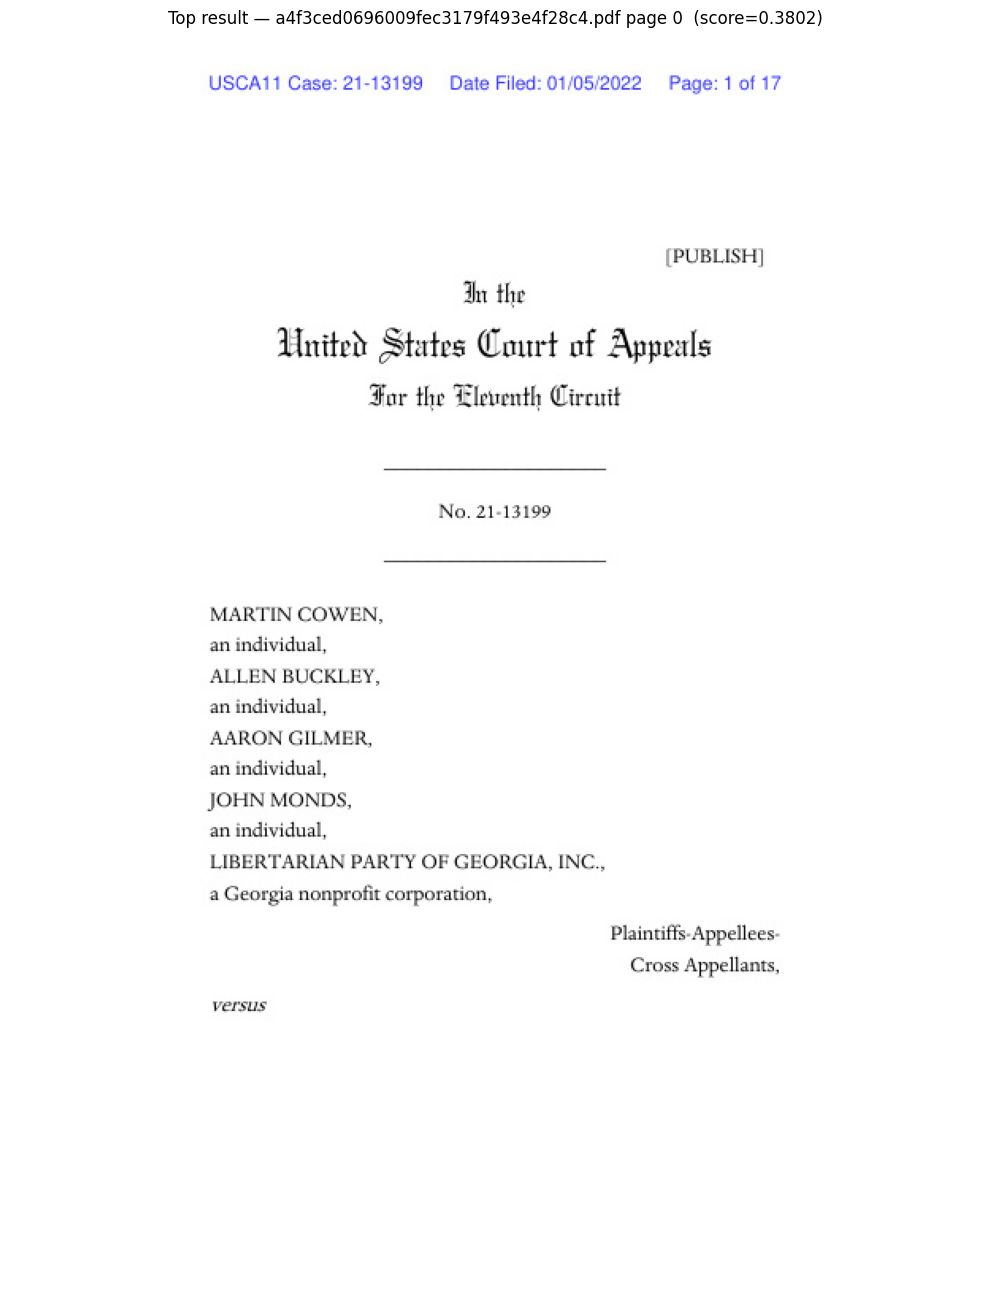

: 

In [ ]:
# Visual check: display the top retrieved image
from PIL import Image
import matplotlib.pyplot as plt

if results:
    top_result = results[0]
    img = Image.open(top_result["image_paths"][0])
    plt.figure(figsize=(10, 14))
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Top result — {top_result['pdf_name']} page {top_result['page_num']}  (score={top_result['score']:.4f})")
    plt.tight_layout()
    plt.show()


## PDF Extraction Fix — font-encoded PDFs
Testing `pdftotext` as fallback for PDFs where pdfplumber returns `(cid:XX)` garbage.

In [4]:
import subprocess
import pdfplumber
from pathlib import Path

PDF_PATH = Path('../project_collection/train/pdf_train/afe620b9beac86c1027b96d31d396407.pdf')

def is_cid_garbage(text: str, threshold: float = 0.3) -> bool:
    if not text:
        return True
    cid_count = text.count('(cid:')
    cid_chars = cid_count * 8
    return cid_chars / max(len(text), 1) > threshold

with pdfplumber.open(PDF_PATH) as pdf:
    page0_text = pdf.pages[0].extract_text() or ''

print(f'pdfplumber page 0 ({len(page0_text)} chars):')
print(repr(page0_text[:200]))
print(f'\nIs garbage: {is_cid_garbage(page0_text)}')


pdfplumber page 0 (15705 chars):
'(cid:5)’(cid:21).(cid:24)+4(cid:21)35?(cid:21).!4(cid:21)+?@?(cid:28)(cid:20)-(cid:20) .(cid:28).-+?(cid:5)’3(cid:24)233’4-?(cid:20)-(cid:5)?(cid:20)-(cid:20)<(cid:1)3’3\n(cid:1)(cid:2)(cid:3)(cid:4)(c'

Is garbage: True


In [5]:
def extract_with_pdftotext(pdf_path: Path):
    with pdfplumber.open(pdf_path) as pdf:
        n_pages = len(pdf.pages)
    blocks = []
    for page_num in range(1, n_pages + 1):
        result = subprocess.run(
            ['pdftotext', '-layout', '-f', str(page_num), '-l', str(page_num), str(pdf_path), '-'],
            capture_output=True, text=True
        )
        text = result.stdout.strip()
        if text:
            blocks.append({'text': text, 'page_number': page_num})
    return blocks

blocks = extract_with_pdftotext(PDF_PATH)
print(f'Extracted {len(blocks)} pages via pdftotext')
print(f'\nPage 1 preview:')
print(blocks[0]['text'][:400])


Extracted 20 pages via pdftotext

Page 1 preview:
DIRECTORS' REPORT & MANAGEMENT DISCUSSION AND ANALYSIS

Your Directors have pleasure in submitting their Annual Report and Accounts of the Company for the year
ended 31st March 2003.


GENERAL ECONOMIC ENVIRONMENT


Against a forecast GDP growth of 6.7%, India achieved a GDP growth of 4.3%. In the first two quarters the
growth was 5.3% and 5.2%. The growth slowed dramatically in the third quarter 


In [6]:
def extract_pdf_robust(pdf_path: Path):
    """pdfplumber per page; fallback to pdftotext on any page with (cid:XX) garbage."""
    blocks = []
    used_fallback = False
    with pdfplumber.open(pdf_path) as pdf:
        for page_num, page in enumerate(pdf.pages, 1):
            text = page.extract_text() or ''
            if is_cid_garbage(text):
                result = subprocess.run(
                    ['pdftotext', '-layout', '-f', str(page_num), '-l', str(page_num),
                     str(pdf_path), '-'],
                    capture_output=True, text=True
                )
                text = result.stdout.strip()
                used_fallback = True
            if text:
                blocks.append({'text': text, 'page_number': page_num})
    return blocks, used_fallback

blocks, used_fallback = extract_pdf_robust(PDF_PATH)
print(f'Pages: {len(blocks)}, used pdftotext fallback: {used_fallback}')
print(f'\nPage 1 preview:')
print(blocks[0]['text'][:400])


Pages: 20, used pdftotext fallback: True

Page 1 preview:
DIRECTORS' REPORT & MANAGEMENT DISCUSSION AND ANALYSIS

Your Directors have pleasure in submitting their Annual Report and Accounts of the Company for the year
ended 31st March 2003.


GENERAL ECONOMIC ENVIRONMENT


Against a forecast GDP growth of 6.7%, India achieved a GDP growth of 4.3%. In the first two quarters the
growth was 5.3% and 5.2%. The growth slowed dramatically in the third quarter 


## Regenerate all_documents.json
Re-processes all PDFs with pdftotext fallback for font-encoded files.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path('..').resolve()))

from data.loaders import process_all_pdfs, save_read_pdf_data

PDF_DIR = Path('../project_collection/train/pdf_train')
OUTPUT_PATH = Path('../data/all_documents.json')

print(f'PDF dir: {PDF_DIR}')
print(f'PDF dir exists: {PDF_DIR.exists()}')
print(f'Output path: {OUTPUT_PATH}')
print(f'Number of PDFs: {len(list(PDF_DIR.glob("*.pdf")))}')


PDF dir: ../project_collection/train/pdf_train
PDF dir exists: True
Output path: ../data/all_documents.json
Number of PDFs: 131


In [ ]:
import os
os.environ["PATH"] = "/opt/homebrew/bin:" + os.environ.get("PATH", "")

from pathlib import Path
from data.loaders import extract_text_from_pdf, save_read_pdf_data
import json
import logging
logging.getLogger('pdfminer').setLevel(logging.ERROR)
logging.getLogger('pikepdf').setLevel(logging.ERROR)
logging.getLogger('pikepdf._core').setLevel(logging.ERROR)
logging.getLogger('numexpr').setLevel(logging.ERROR)

import time

start = time.time()
all_documents = process_all_pdfs(PDF_DIR)
elapsed = time.time() - start

print(f'\nProcessed {len(all_documents)} documents in {elapsed:.1f}s')


INFO:data.loaders:Found 131 PDF files
INFO:data.loaders:Processing PDF 1/131
INFO:data.loaders:Processing PDF 11/131
INFO:data.loaders:Processing PDF 21/131
ERROR:data.loaders:Error processing ../project_collection/train/pdf_train/afe620b9beac86c1027b96d31d396407.pdf: [Errno 2] No such file or directory: 'pdftotext'
ERROR:data.loaders:Error processing ../project_collection/train/pdf_train/amb-siteaudits-ds15-150204174043-conversion-gate01_95.pdf: Unable to get page count. Is poppler installed and in PATH?


KeyboardInterrupt: 

In [4]:
import os
os.environ["PATH"] = "/opt/homebrew/bin:" + os.environ.get("PATH", "")

from pathlib import Path
from data.loaders import extract_text_from_pdf, save_read_pdf_data
import json

PDF_DIR = Path("../project_collection/train/pdf_train")

failed_names = [
    "afe620b9beac86c1027b96d31d396407.pdf",
    "amb-siteaudits-ds15-150204174043-conversion-gate01_95.pdf",
    "NUS-FASS-Graduate-Guidebook-2021-small.pdf",
    "germanwingsdigitalcrisisanalysis-150403064828-conversion-gate01_95.pdf",
    "earthlinkweb-150213112111-conversion-gate02_95.pdf",
    "earlybird-110722143746-phpapp02_95.pdf",
    "measuringsuccessonfacebooktwitterlinkedin-160317142140_95.pdf",
    "reportq32015-151009093138-lva1-app6891_95.pdf",
    "digitalmeasurementframework22feb2011v6novideo-110221233835-phpapp01_95.pdf",
    "nielsen2015musicbizpresentation-final-150526143534-lva1-app6891_95.pdf",
    "finalpresentationdeck-whatwhyhowofcertificationsocial-160324220748_95.pdf",
    "efis-140411041451-phpapp01_95.pdf",
    "bariumswallowpresentation-090810084400-phpapp01_95.pdf",
    "formwork-150318073913-conversion-gate01_95.pdf",
    "asdaaburson-marstellerarabyouthsurvey2014-140407100615-phpapp01_95.pdf",
    "ecommerceopportunityindia-141124010546-conversion-gate01_95.pdf",
    "competitiveoutcomes-091006065143-phpapp01_95.pdf",
    "bigdatatrends-120723191058-phpapp02_95.pdf",
    "bdf54dxa.pdf",
    "dr-vorapptchapter1emissionsources-121120210508-phpapp02_95.pdf",
    "ddoseattle-150627210357-lva1-app6891_95.pdf",
    "chapter8-geneticscompatibilitymode-141214140247-conversion-gate02_95.pdf",
    "finalmediafindingspdf-141228031149-conversion-gate02_95.pdf",
    "avalaunchpresentationsthatkickasteriskv3copy-150318114804-conversion-gate01_95.pdf",
    "catvsdogdlpycon15se-150512122612-lva1-app6891_95.pdf",
    "disciplined-agile-business-analysis-160218012713_95.pdf",
    "b3m5kaeqm2w8n4bwcesw-140602121350-phpapp02_95.pdf",
    "caltraincapacitymountainview1-150701205750-lva1-app6891_95.pdf",
    "indonesiamobilemarketresearch-ag-150106055934-conversion-gate02_95.pdf",
]

retry_docs = []
for name in failed_names:
    doc = extract_text_from_pdf(PDF_DIR / name)
    if doc:
        retry_docs.append(doc)

print(f"Recovered {len(retry_docs)}/29 PDFs")



Recovered 29/29 PDFs


NameError: name 'existing' is not defined

In [5]:
print(f"Recovered {len(retry_docs)}/29 PDFs")

Recovered 29/29 PDFs


In [8]:

all_documents.extend(retry_docs)

save_read_pdf_data(all_documents, "all_documents.json")
print(f"Total: {len(all_documents)} documents saved")


Total: 189 documents saved


In [9]:
import json

with open("all_documents.json") as f:
    docs = json.load(f)

seen = {}
for doc in docs:
    name = doc["pdf_name"]
    # keep the later one (OCR version has more/better text for image PDFs)
    seen[name] = doc

deduped = list(seen.values())
print(f"Before: {len(docs)}, After: {len(deduped)}")

with open("all_documents.json", "w", encoding="utf-8") as f:
    json.dump(deduped, f, ensure_ascii=False, indent=2)


Before: 189, After: 131


In [14]:
# Verify the problematic PDF is now clean
target = 'afe620b9beac86c1027b96d31d396407.pdf'
doc = next((d for d in all_documents if d['pdf_name'] == target), None)

if doc:
    print(f'Found {target}')
    print(f'Blocks: {len(doc["blocks"])}')
    print(f'\nFirst block text preview:')
    print(doc['blocks'][0]['text'][:300])
else:
    print(f'NOT FOUND: {target}')


Found afe620b9beac86c1027b96d31d396407.pdf
Blocks: 20

First block text preview:
DIRECTORS' REPORT & MANAGEMENT DISCUSSION AND ANALYSIS

Your Directors have pleasure in submitting their Annual Report and Accounts of the Company for the year
ended 31st March 2003.


GENERAL ECONOMIC ENVIRONMENT


Against a forecast GDP growth of 6.7%, India achieved a GDP growth of 4.3%. In the f


In [ ]:
# Save to all_documents.json
save_read_pdf_data(all_documents, path=str(OUTPUT_PATH))
print(f'Saved {len(all_documents)} documents to {OUTPUT_PATH}')
print(f'File size: {OUTPUT_PATH.stat().st_size / 1024 / 1024:.1f} MB')


In [13]:
print(f"Total documents: {len(all_documents)}")
missing = []
all_names = {d['pdf_name'] for d in all_documents}
for pdf in PDF_DIR.glob("*.pdf"):
    if pdf.name not in all_names:
        missing.append(pdf.name)
print(f"Missing {len(missing)} PDFs:")
for m in missing:
    print(f"  {m}")


Total documents: 104
Missing 27 PDFs:
  amb-siteaudits-ds15-150204174043-conversion-gate01_95.pdf
  NUS-FASS-Graduate-Guidebook-2021-small.pdf
  germanwingsdigitalcrisisanalysis-150403064828-conversion-gate01_95.pdf
  earthlinkweb-150213112111-conversion-gate02_95.pdf
  earlybird-110722143746-phpapp02_95.pdf
  measuringsuccessonfacebooktwitterlinkedin-160317142140_95.pdf
  reportq32015-151009093138-lva1-app6891_95.pdf
  digitalmeasurementframework22feb2011v6novideo-110221233835-phpapp01_95.pdf
  nielsen2015musicbizpresentation-final-150526143534-lva1-app6891_95.pdf
  finalpresentationdeck-whatwhyhowofcertificationsocial-160324220748_95.pdf
  efis-140411041451-phpapp01_95.pdf
  bariumswallowpresentation-090810084400-phpapp01_95.pdf
  formwork-150318073913-conversion-gate01_95.pdf
  asdaaburson-marstellerarabyouthsurvey2014-140407100615-phpapp01_95.pdf
  ecommerceopportunityindia-141124010546-conversion-gate01_95.pdf
  competitiveoutcomes-091006065143-phpapp01_95.pdf
  bigdatatrends-1207

Chunking

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from typing import List, Dict, Any
from unstructured.partition.auto import partition
from types import SimpleNamespace

from pathlib import Path
import json

class Chunking:
    HEADING_CATEGORIES = {"Title", "Header"}

    def __init__(self, blocks: List):
        self.blocks = blocks

    @staticmethod
    def _make_chunk(
        texts: List[str], extra_meta: Dict[str, Any] = None
    ) -> Dict[str, Any]:
        """Helper function to store char_len which can be useful downstream"""
        chunk_text = " ".join(texts)
        chunk = {"text": chunk_text, "char_len": len(chunk_text)}
        if extra_meta:
            chunk.update(extra_meta)
        return chunk

    @staticmethod
    def _split_oversized(chunks: List[Dict[str, Any]], max_chars: int = 8000) -> List[Dict[str, Any]]:
        """
        Split any chunk exceeding max_chars into fixed-size sub-chunks.
        Preserves all metadata from the original chunk.
        """
        result = []
        for chunk in chunks:
            if chunk["char_len"] <= max_chars:
                result.append(chunk)
                continue
            text = chunk["text"]
            meta = {k: v for k, v in chunk.items() if k not in ("text", "char_len")}
            for i in range(0, len(text), max_chars):
                sub_text = text[i:i + max_chars]
                result.append({"text": sub_text, "char_len": len(sub_text), **meta})
        return result


    def fixed_size(self, max_chars: int = 1000) -> List[Dict[str, Any]]:
        """Concatenate blocks until max_chars is exceeded, then start a new chunk."""

        current_texts, chunks = [], []
        text_len, blocks_count = 0, len(self.blocks)
        page_numbers = {"page_numbers": set()}
        for i, block in enumerate(self.blocks):
            text = block.text.strip()
            page_numbers["page_numbers"].add(block.page_number)
            if not text:
                continue

            text_len += len(text)
            current_texts.append(text)
            if text_len > max_chars or i == blocks_count - 1:
                page_numbers = {"page_numbers": list(page_numbers["page_numbers"])}
                chunks.append(Chunking._make_chunk(current_texts, page_numbers))
                current_texts = []
                page_numbers = {"page_numbers": set()}
                text_len = 0
        return chunks
    
    
    def sliding_window(
        self, window_charts: int = 1000, overlap_chars: int = 200
    ) -> List[Dict[str, Any]]:
        """
        Fixed-size windows with overlap so context at chunk boundaries
        is not lost. Good for dense text documents.
        """
        current_texts, chunks = [], []
        text_len, blocks_count = 0, len(self.blocks)
        page_numbers = {"page_numbers": set()}
        for i, block in enumerate(self.blocks):
            text = block.text.strip()
            page_numbers["page_numbers"].add(block.page_number)
            if not text:
                continue

            text_len += len(text)
            current_texts.append(text)
            if text_len > window_charts or i == blocks_count - 1:
                if chunks:
                    prev_text = chunks[-1]["text"][
                        -overlap_chars:
                    ]  # use the actual text from the last chunk
                    current_texts = [prev_text] + current_texts
                else:
                    prev_text = ""
                page_numbers = {"page_numbers": list(page_numbers["page_numbers"])}
                current_texts.append(prev_text)
                chunks.append(Chunking._make_chunk(current_texts, page_numbers))
                current_texts = []
                page_numbers = {"page_numbers": set()}
                text_len = overlap_chars

        return chunks
    
    def semantic(self) -> List[Dict[str, Any]]:
        """
        Group blocks into sections separated by title/header elements.
        Each heading starts a new chunk. This keeps the documents natural
        semantic boundaries intact.

        Consecutive headers without body text are merged forward so they
        attach to the next chunk that has actual content.
        """

        current_texts, chunks = [], []
        chunk_contains_text = False
        page_numbers = {"page_numbers": set()}
        for block in self.blocks:
            text = block.text.strip()
            page_numbers["page_numbers"].add(block.page_number)
            if not text:
                continue

            if block.category in self.HEADING_CATEGORIES:
                # Only flush if the current chunk has body text
                if chunk_contains_text:
                    page_numbers = {"page_numbers": list(page_numbers["page_numbers"])}
                    chunks.append(Chunking._make_chunk(current_texts, page_numbers))
                    current_texts = []
                    chunk_contains_text = False
                    page_numbers = {"page_numbers": set()}

                current_texts.append(text)

            else:
                current_texts.append(text)
                chunk_contains_text = True

        # Add remaining - but if it's only headers, merge into the last chunk
        if current_texts:
            if chunk_contains_text or not chunks:
                page_numbers = {"page_numbers": list(page_numbers["page_numbers"])}
                chunks.append(Chunking._make_chunk(current_texts, page_numbers))
                page_numbers = {"page_numbers": set()}
            else:
                # Trailing headers only - append to previous chunk
                prev = chunks[-1]
                combined = prev["text"] + " " + " ".join(current_texts)
                chunks[-1] = {"text": combined, "char_len": len(combined)}

        return self._split_oversized(chunks)
    def hierarchical(self) -> List[Dict[str, Any]]:
        """
        Two-level hierarchy:
          - Level 1 (parent): full page text  (coarse retrieval)
          - Level 2 (child):  per-section text within each page  (fine retrieval)

        Returns a flat list but each chunk's metadata includes
        'level' ('page' or 'section') and 'page_number'.
        """
        # Group blocks by page number
        pages: dict[int, list] = {}
        for block in self.blocks:
            page = getattr(block, "page_number", None) or 0
            pages.setdefault(page, []).append(block)

        hierarchical_pages: list[dict] = []

        for page_num in sorted(pages):
            page_blocks = pages[page_num]
            page_texts = [b.text.strip() for b in page_blocks if b.text.strip()]

            if not page_texts:
                continue

            # Parent chunk: whole page
            page_chunk = Chunking._make_chunk(
                page_texts,
                extra_meta={"level": "page", "page_numbers": [page_num]},
            )


            # Child chunks: split by headings within the page
            page_sections: list[dict] = []
            section_texts: list[str] = []
            has_body = False
            for block in page_blocks:
                text = block.text.strip()
                if not text:
                    continue
                if block.category in self.HEADING_CATEGORIES:
                    if has_body and section_texts:
                        page_sections.append(
                            Chunking._make_chunk(
                                section_texts,
                                extra_meta={"level": "section", "page_numbers": [page_num]},
                            )
                        )
                        section_texts = []
                        has_body = False
                    section_texts.append(text)
                else:
                    section_texts.append(text)
                    has_body = True

            if section_texts:
                if has_body or not page_sections:
                    page_sections.append(
                        Chunking._make_chunk(
                            section_texts,
                            extra_meta={"level": "section", "page_numbers": [page_num]},
                        )
                    )
                else:
                    # Trailing headers - merge into last section chunk for this page
                    prev = page_sections[-1]
                    combined = prev["text"] + " " + " ".join(section_texts)
                    page_sections[-1] = {**prev, "text": combined, "char_len": len(combined)}

            # 3. Nest children inside the parent and append to final list
            page_chunk["chunks"] = page_sections
            hierarchical_pages.append(page_chunk)

        return self._split_oversized(hierarchical_pages)

    def enhanced_hierarchical(self) -> List[Dict[str, Any]]:
        """
        Optimized Two-level hierarchy (Cross-Page):
        - Level 1 (parent): Full Section (Starts at a Heading, ends at the next Heading)
        - Level 2 (child): Individual paragraphs/blocks within that section.
        
        This prevents context loss when a logical section spills across a physical page break.
        """
        hierarchical_sections: List[Dict[str, Any]] = []
        
        # State tracking for the current section
        current_parent_title = "Document Start" # Default if no header exists at the very beginning
        current_children: List[Dict[str, Any]] = []
        current_parent_texts: List[str] = []
        current_pages = set() # Using a set to track all pages this section spans
        
        for block in self.blocks:
            text = block.text.strip()
            if not text:
                continue
                
            # Get page number safely, default to 0 if missing
            page_num = getattr(block, "page_number", None) or 0
            is_heading = block.category in getattr(self, "HEADING_CATEGORIES", [])
            
            if is_heading:
                # 1. Flush the previous section to our list before starting this new one
                if current_children or current_parent_texts:
                    parent_chunk = self._make_chunk(
                        current_parent_texts,
                        extra_meta={
                            "level": "section", 
                            "title": current_parent_title,
                            "page_numbers": sorted(list(current_pages)) # e.g., [1, 2]
                        }
                    )
                    parent_chunk["chunks"] = current_children
                    hierarchical_sections.append(parent_chunk)

                
                # 2. Reset the state for the new section
                current_parent_title = text
                current_children = []
                current_parent_texts = [text]
                current_pages = {page_num}
                
            else:
                # 3. We are inside a section body. Append text and track the page.
                current_parent_texts.append(text)
                current_pages.add(page_num)
                
                # Create a child chunk for this specific paragraph/block
                current_children.append(
                    self._make_chunk(
                        [text],
                        extra_meta={
                            "level": "paragraph", 
                            "page_numbers": [page_num],
                            "parent_title": current_parent_title
                        }
                    )
                )
                
        # 4. Flush the final section after the loop finishes
        if current_children or current_parent_texts:
            parent_chunk = self._make_chunk(
                current_parent_texts,
                extra_meta={
                    "level": "section", 
                    "title": current_parent_title,
                    "page_numbers": sorted(list(current_pages))
                }
            )
            parent_chunk["chunks"] = current_children
            hierarchical_sections.append(parent_chunk)
            
        return self._split_oversized(hierarchical_sections)

def save_read_pdf_data(all_documents):
    serializable = []
    for doc in all_documents:
        serializable.append({
            "pdf_name": doc["pdf_name"],
            "pdf_path": doc["pdf_path"],
            "blocks": [{
                "category": b.category,
                "text": b.text,
                "page_number": b.metadata.to_dict().get("page_number")
            } for b in doc["blocks"]]
        })

    with open("../data/all_documents.json", "w", encoding="utf-8") as f:
        json.dump(serializable, f, ensure_ascii=False, indent=2)
        
    
def save_chunked_pdf_data(all_chunked_docs, path):
    with open(path, "w", encoding="utf-8") as f:
        json.dump(all_chunked_docs, f, ensure_ascii=False, indent=2)

def load_read_documents(path):
    with open(path, "r", encoding="utf-8") as f:
        docs = json.load(f)
    for doc in docs:
        doc["blocks"] = [
            SimpleNamespace(
                category=b["category"],
                text=b["text"],
                page_number=b["page_number"]
            ) for b in doc["blocks"]
        ]
    return docs
        

In [7]:
all_documents = load_read_documents("../data/preprocessed/all_documents.json")

chunk_methods = {
    "fixed_size": lambda c: c.fixed_size(),
    "sliding_window": lambda c: c.sliding_window(),
    "semantic": lambda c: c.semantic(),
    "hierarchical": lambda c: c.hierarchical(),
    "enhanced_hierarchical": lambda c: c.enhanced_hierarchical(),
}

for method_name, method_fn in chunk_methods.items():
    all_chunked_docs = []  # reset per method

    for doc in all_documents:
        chunker = Chunking(doc["blocks"])

        chunked_doc = {
            **doc,
            "chunks": method_fn(chunker),
        }

        chunked_doc.pop("blocks", None)
        all_chunked_docs.append(chunked_doc)

    # save ONE file per method
    save_chunked_pdf_data(all_chunked_docs, path=f"../data/chunks_{method_name}.json")